In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch.nn import functional as F
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from domain_shift.core.config import settings
from domain_shift.CycleGAN.data_loader import get_data_loader
from domain_shift.CycleGAN.models import Generator, CycleGAN
from domain_shift.data_extraction.process_DRIAMS import DRIAMS_bin_to_df

In [2]:
# Load the data
driams_1 = DRIAMS_bin_to_df(settings.DRIAMS_C_PATH)
driams_2 = DRIAMS_bin_to_df(settings.DRIAMS_D_PATH)

In [3]:
# Combine the 'species' columns from both datasets
combined_species = pd.concat([driams_1['species'], driams_2['species']])

# Find the most represented species across both datasets
most_represented_species = combined_species.value_counts().idxmax()
most_represented_species

'Escherichia coli'

In [4]:
# Show the distribution of the most represented species in each dataset
driams_1['species'].value_counts()[most_represented_species], \
driams_2['species'].value_counts()[most_represented_species]

(np.int64(927), np.int64(2013))

In [5]:
# Filter by the 4 species with most representation
filtered_driams_1 = driams_1[driams_1["species"].isin([most_represented_species])]
filtered_driams_2 = driams_2[driams_2["species"].isin([most_represented_species])]

In [6]:
# Get the data loaders
driams_1_data_loader = get_data_loader(filtered_driams_1)
driams_2_data_loader = get_data_loader(filtered_driams_2)

print("DataLoader 1 length:", len(driams_1_data_loader))
print("DataLoader 2 length:", len(driams_2_data_loader))

DataLoader 1 length: 309
DataLoader 2 length: 671


In [7]:
# Train the CycleGAN
cycle_gan = CycleGAN()
cycle_gan.train(driams_1_data_loader, driams_2_data_loader)

Epoch 1/20, Loss G: 2.161129951477051, Loss D 1: 0.025232063606381416, Loss D 2: 0.0560244545340538
Epoch 2/20, Loss G: 0.6885465383529663, Loss D 1: 0.276156485080719, Loss D 2: 0.23426279425621033
Epoch 3/20, Loss G: 0.6161313056945801, Loss D 1: 0.24273747205734253, Loss D 2: 0.24277281761169434
Epoch 4/20, Loss G: 0.5650167465209961, Loss D 1: 0.2475200742483139, Loss D 2: 0.2485598772764206
Epoch 5/20, Loss G: 0.9122653603553772, Loss D 1: 0.26625385880470276, Loss D 2: 0.20481830835342407
Epoch 6/20, Loss G: 0.7392339110374451, Loss D 1: 0.2196113020181656, Loss D 2: 0.20991310477256775
Epoch 7/20, Loss G: 1.1437909603118896, Loss D 1: 0.17524464428424835, Loss D 2: 0.21001483500003815
Epoch 8/20, Loss G: 0.9629467725753784, Loss D 1: 0.13261494040489197, Loss D 2: 0.15308627486228943
Epoch 9/20, Loss G: 1.1065267324447632, Loss D 1: 0.24529121816158295, Loss D 2: 0.1864098310470581
Epoch 10/20, Loss G: 1.4079798460006714, Loss D 1: 0.10358884930610657, Loss D 2: 0.16329139471054

In [12]:
# Calculate min and max values
identity_min, identity_max = 10 * min(cycle_gan.identity_error_loss), 10 * max(cycle_gan.identity_error_loss)
gan_min, gan_max = min(cycle_gan.gan_error_loss), max(cycle_gan.gan_error_loss)
cycle_min, cycle_max = 10 * min(cycle_gan.cycle_error_loss), 10 * max(cycle_gan.cycle_error_loss)

# Print min and max values
print(f"Identity Error Loss: Min = {identity_min}, Max = {identity_max}")
print(f"GAN Error Loss: Min = {gan_min}, Max = {gan_max}")
print(f"Cycle Error Loss: Min = {cycle_min}, Max = {cycle_max}")

Identity Error Loss: Min = 0.8420166373252869, Max = 358.98651123046875
GAN Error Loss: Min = 199.30821228027344, Max = 622.8441772460938
Cycle Error Loss: Min = 0.9907985478639603, Max = 352.3377990722656


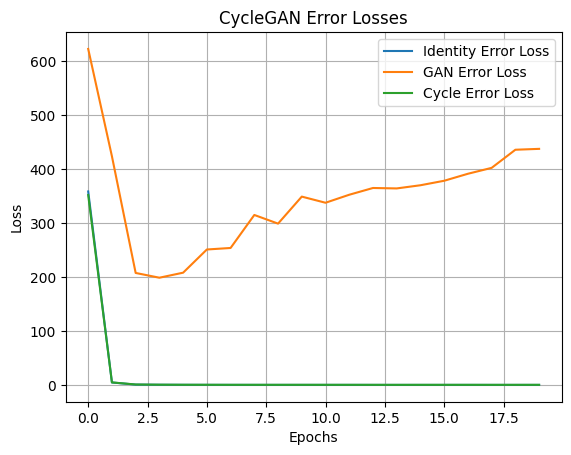

In [11]:
# Graph cycle_gan.identity_error_loss, cycle_gan.gan_error_loss, cycle_gan.cycle_error_loss
plt.plot([error * 10 for error in cycle_gan.identity_error_loss], label='Identity Error Loss')
plt.plot(cycle_gan.gan_error_loss, label='GAN Error Loss')
plt.plot([error * 10 for error in cycle_gan.cycle_error_loss], label='Cycle Error Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CycleGAN Error Losses')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Train Random Forest on DRIAMS 1
X = np.vstack(driams_1["binned_6000"].values)
y = driams_1["species"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

f1_score(y_test, y_pred, average='weighted')

0.936847637188883

In [16]:
# Test the model on the filtered driams 2
X = np.vstack(filtered_driams_2["binned_6000"].values)
y = filtered_driams_2["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

0.8155339805825242

In [17]:
# Generate the synthetic data
synthetic_driams_2 = []
for data in driams_2_data_loader:
    output = cycle_gan.generator_2_to_1(data.to("cuda")).cpu().detach()
    synthetic_driams_2.extend(output.cpu().detach().flatten(1))
synthetic_driams_2 = torch.stack(synthetic_driams_2)

# Test the model on the synthetic driams 2
X = np.vstack(synthetic_driams_2.numpy())
y = filtered_driams_2["species"].values

y_pred = rf.predict(X)

f1_score(y, y_pred, average='weighted')

0.8520102651839179